# 01 — Baseline Training: ResNet-50 on PlantVillage

Fine-tune a pretrained ResNet-50 on the PlantVillage (color) dataset.

**Pipeline**
1. Build stratified 70/15/15 train/val/test dataloaders
2. Load pretrained ResNet-50, replace head for 38-class classification
3. Train with Adam + cosine-annealing LR schedule
4. Save best checkpoint (lowest val loss)
5. Plot loss and accuracy curves

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# Make src/ importable from the notebooks/ directory
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data  import make_pv_loaders
from src.model import build_model, count_params

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA GeForce RTX 5060


## 1. Hyperparameters

In [2]:
# Adjust these before running
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_EPOCHS  = 10
LR          = 3e-4
NUM_WORKERS = 0     # must be 0 on Windows as multiprocessing deadlocks in notebooks
SEED        = 42
CKPT_PATH   = ROOT / "models" / "resnet50_pv_best.pt"

torch.manual_seed(SEED)
print(f"Device         : {DEVICE}")
print(f"Checkpoint     : {CKPT_PATH}")


Device         : cuda
Checkpoint     : C:\Users\jakev\Documents\2026 Spring Semester\CPTS 434\Leaf-Health-Analyzer\models\resnet50_pv_best.pt


## 2. Dataloaders

In [3]:
train_loader, val_loader, test_loader, classes = make_pv_loaders(
    root=ROOT,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)

print(f"Classes  : {len(classes)}")
print(f"Train    : {len(train_loader.dataset):,} images  ({len(train_loader)} batches)")
print(f"Val      : {len(val_loader.dataset):,} images  ({len(val_loader)} batches)")
print(f"Test     : {len(test_loader.dataset):,} images  ({len(test_loader)} batches)")

Classes  : 38
Train    : 38,013 images  (594 batches)
Val      : 8,146 images  (128 batches)
Test     : 8,146 images  (128 batches)


## 3. Model

In [4]:
model = build_model(
    arch="resnet50",
    num_classes=len(classes),
    task="single",
    pretrained=True,
    freeze_backbone=False,
).to(DEVICE)

p = count_params(model)
print(f"Parameters — total: {p['total']:,}  trainable: {p['trainable']:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\jakev/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 63.2MB/s]


Parameters — total: 23,585,894  trainable: 23,585,894


## 4. Training loop

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")


def run_epoch(loader, training: bool, desc: str = ""):
    """Run one epoch; return (avg_loss, accuracy)."""
    model.train() if training else model.eval()
    total_loss = correct = seen = 0

    # inference_mode is faster than no_grad for eval (skips version tracking)
    ctx = torch.enable_grad if training else torch.inference_mode
    with ctx():
        for imgs, labels in tqdm(loader, desc=desc, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            seen       += imgs.size(0)

    return total_loss / seen, correct / seen


for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    tr_loss, tr_acc = run_epoch(train_loader, training=True,  desc=f"E{epoch:02d} train")
    vl_loss, vl_acc = run_epoch(val_loader,   training=False, desc=f"E{epoch:02d} val  ")
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss":    vl_loss,
            "val_acc":     vl_acc,
            "classes":     classes,
        }, CKPT_PATH)

    tqdm.write(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} "
        f"| train loss {tr_loss:.4f}  acc {tr_acc:.4f} "
        f"| val loss {vl_loss:.4f}  acc {vl_acc:.4f}"
        + ("  [saved]" if vl_loss == best_val_loss else "")
    )

print(f"\nBest val loss: {best_val_loss:.4f}  (checkpoint: {CKPT_PATH.name})")


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

E01 train:   0%|          | 0/594 [00:00<?, ?it/s]

E01 val  :   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.2579  acc 0.9214 | val loss 0.1907  acc 0.9398  [saved]


E02 train:   0%|          | 0/594 [00:00<?, ?it/s]

...

E09 val  :   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.0074  acc 0.9979 | val loss 0.0085  acc 0.9964  [saved]


E10 train:   0%|          | 0/594 [00:00<?, ?it/s]

E10 val  :   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.0049  acc 0.9985 | val loss 0.0074  acc 0.9971  [saved]

Best val loss: 0.0074  (checkpoint: resnet50_pv_best.pt)


## 5. Learning curves

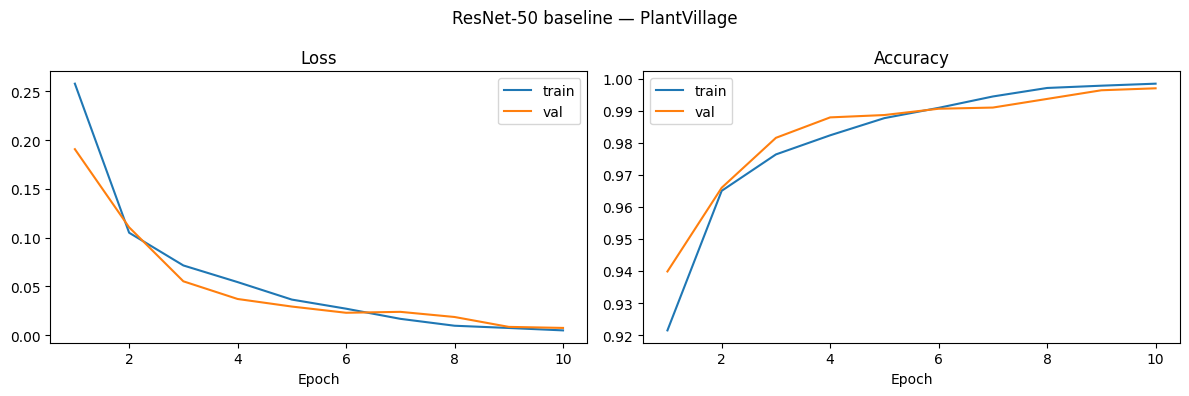

Final val accuracy : 0.9971
Best  val accuracy : 0.9971


In [6]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"],   label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("ResNet-50 baseline — PlantVillage", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "models" / "resnet50_pv_curves.png", dpi=150)
plt.show()

print(f"Final val accuracy : {history['val_acc'][-1]:.4f}")
print(f"Best  val accuracy : {max(history['val_acc']):.4f}")